In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Classes:", data.target_names)

Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


In [4]:
#logistic regression 

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))
    
#training using gradient descent

def logistic_train(X, y, lr=0.05, epochs=3000):
    X = np.c_[np.ones(X.shape[0]), X]
    w = np.zeros(X.shape[1])

    for _ in range(epochs):
        z = X @ w
        p = sigmoid(z)

        gradient = (X.T @ (p - y)) / len(y)
        w = w - lr * gradient

    return w
    
#prediction

def logistic_predict(X, w):
    X = np.c_[np.ones(X.shape[0]), X]

    probability = sigmoid(X @ w)

    return (probability >= 0.5).astype(int)

#train the modeel

w_lr = logistic_train(X_train, y_train)

y_pred_lr = logistic_predict(X_test, w_lr)

print("Logistic Regression completed.")

Logistic Regression completed.


In [5]:
#perceptron 

def perceptron_train(X, y, lr=0.01, epochs=1000):
    X = np.c_[np.ones(X.shape[0]), X]
    y = np.where(y == 0, -1, 1)

    w = np.zeros(X.shape[1])

    for _ in range(epochs):
        for xi, yi in zip(X, y):

            if yi * (xi @ w) <= 0:
                w = w + lr * yi * xi

    return w

#prediction

def perceptron_predict(X, w):
    X = np.c_[np.ones(X.shape[0]), X]

    return (X @ w >= 0).astype(int)

#train the perceptron

w_p = perceptron_train(X_train, y_train)

y_pred_p = perceptron_predict(X_test, w_p)

print("Perceptron completed.")

Perceptron completed.


In [8]:
#evaluate both model
def evaluate_model(name, y_true, y_pred):

    print("\n", name)
    print("-" * 30)

    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1-Score :", round(f1_score(y_true, y_pred), 4))

evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

evaluate_model(
    "Perceptron",
    y_test,
    y_pred_p
)




 Logistic Regression
------------------------------
Accuracy : 0.9649
Precision: 0.9857
Recall   : 0.9583
F1-Score : 0.9718

 Perceptron
------------------------------
Accuracy : 0.9386
Precision: 0.971
Recall   : 0.9306
F1-Score : 0.9504


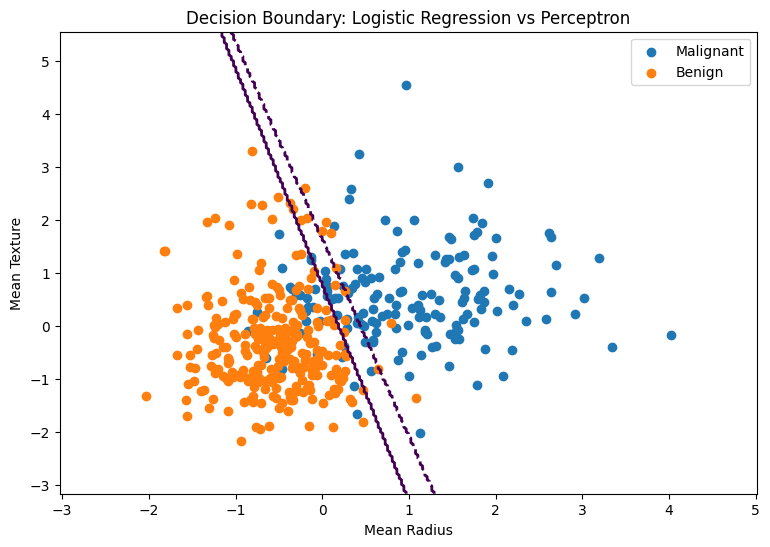

In [9]:
#decision boundary using two features 
X2 = data.data[:, :2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler2 = StandardScaler()

X2_train = scaler2.fit_transform(X2_train)

w_lr2 = logistic_train(X2_train, y2_train)
w_p2 = perceptron_train(X2_train, y2_train)

#create mesh grid for decision boundary 

x_min = X2_train[:, 0].min() - 1
x_max = X2_train[:, 0].max() + 1

y_min = X2_train[:, 1].min() - 1
y_max = X2_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z_lr = logistic_predict(grid, w_lr2).reshape(xx.shape)

Z_p = perceptron_predict(grid, w_p2).reshape(xx.shape)

#plot decsion boundary

plt.figure(figsize=(9, 6))

# Data points
plt.scatter(
    X2_train[y2_train == 0, 0],
    X2_train[y2_train == 0, 1],
    label="Malignant"
)

plt.scatter(
    X2_train[y2_train == 1, 0],
    X2_train[y2_train == 1, 1],
    label="Benign"
)

# Logistic Regression boundary
plt.contour(
    xx, yy, Z_lr,
    levels=[0.5],
    linewidths=2
)

# Perceptron boundary
plt.contour(
    xx, yy, Z_p,
    levels=[0.5],
    linewidths=2,
    linestyles="--"
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")

plt.title("Decision Boundary: Logistic Regression vs Perceptron")

plt.legend()
plt.show()